# Mestrado em Informática
## Pós-Graduação em Data Science and Digital Transformation
### (Ambientes de) Programação para Ciência de Dados
### Projeto 2

Aluno: Miguel de Campos Rodrigues (27089)

#### INTRODUÇÃO
A análise de dados desempenha um papel fundamental na compreensão de fenómenos complexos e
no apoio à tomada de decisão informada. No contexto do ensino superior, a análise dos dados
académicos dos estudantes pode contribuir para a identificação precoce de padrões associados ao
sucesso académico, abandono ou prolongamento dos estudos.

Neste projeto, será utilizado um conjunto de dados anonimizados relativo à situação académica de
estudantes de cursos de Licenciatura do Instituto Politécnico de Portalegre, contendo informação
disponível no momento da matrícula. O objetivo final é analisar e preparar os dados para a futura
construção de modelos de aprendizagem máquina capazes de prever, o mais cedo possível no percurso
académico, a situação do estudante ao fim de N anos.

#### CONJUNTO DE DADOS
O conjunto de dados anonimizados encontra-se no ficheiro `dataset_PIAES_reduced.xlsx`.
As características presentes no conjunto de dados dizem respeito a uma parte da informação existente
sobre os estudantes no ato da matrícula, nomeadamente:

>`Sexo` (M/F)  
`Estado civil` (desc)  
`Ordem de ingresso` (opção de preferência de ingresso no curso – 1 representa 1ª opção)  
`Curso`(desc)  
`Deslocado` (S/N)  
`Nacionalidade` (desc)  
`Habilitação literária mãe` (desc)  
`Situação profissional mãe` (desc)  
`Situação profissional pai` (desc)  
`Nota ingresso`  
`Bolseiro` (1 para detentor de bolsa, 0 para o caso contrário)  
`Idade no ingresso`

O campo `Categoria` tem como valores possíveis Diplomado / Não Diplomado e indica se o
estudante obteve ou não o seu diploma ao fim de N anos de frequência do curso de Licenciatura. N
representa a duração de um ciclo de estudos, e tem valor 4 para a Licenciatura em Enfermagem, valor
3 para todos os outros cursos de Licenciatura do IPP.
Na categoria "Não Diplomado" estão incluídos os estudantes que, estando inscritos, ainda não
terminaram os seus cursos ao fim de N anos, e também os estudantes que abandonaram o curso ao
longo do seu percurso académico

In [162]:
import io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
import time

from IPython.core.display import HTML
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [124]:
def is_colab():
    return "google.colab" in sys.modules

def open_excel_colab():
  uploaded = files.upload()
  if uploaded:
    (filename, content) = next(iter(uploaded))
    print('Uploaded file "{name}" with length {length} bytes'.format(
          name=fn, length=len(uploaded[filename])))

    return pd.read_excel(io.BytesIO(content))

def open_excel_local():
  app = wx.App(False)
  dialog = wx.FileDialog(
      None,
      "Choose a Excel file",
      wildcard="Excel files (*.xlsx;*.xls)|*.xlsx;*.xls",
      style=wx.FD_OPEN | wx.FD_FILE_MUST_EXIST
  )

  if dialog.ShowModal() == wx.ID_OK:
      path = dialog.GetPath()
      print("Selected:", path)
      df = pd.read_excel(path)
      dialog.Destroy()
      return df
  else:
      dialog.Destroy()
      print("No file selected.")
      return None

if is_colab():
  from google.colab import files
  open_excel = open_excel_colab
else:
  import wx
  open_excel = open_excel_local

In [125]:
dt = open_excel()

Selected: D:\Mestrado\PCD\src\projeto2\dataset_PIAES_reduced.xlsx


#### Parte 1 — Caracterização inicial dos dados
1. Apresente uma caracterização geral do conjunto de dados: número de observações e de atributos;
tipos de variáveis (numéricas, categóricas, binárias).

In [126]:
dt

,Sexo (M/F),Estado civil (desc),Ordem de ingresso,Curso (desc),Deslocado (S/N),Nacionalidade (desc),Habilitação literária mãe (desc),Situação profissional mãe (desc),Situação profissional pai (desc),Nota ingresso,Bolseiro,Idade no ingresso,Categoria
0,M,Solteiro(a),5,Design de Animação e Multimédia,S,Portuguesa,Outro - 11º Ano de Escolaridade,Trabalhador(a) por Conta de Outrém,Outra Situação (Falecido/a),127.3,0,20.0,Não Diplomado
1,M,Solteiro(a),1,Turismo,S,Portuguesa,Ensino Superior - Licenciatura,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,142.5,0,19.0,Diplomado
2,M,Solteiro(a),5,Design de Comunicação,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Desempregado/a,124.8,0,19.0,Não Diplomado
3,F,Solteiro(a),2,Jornalismo e Comunicação,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,119.6,0,20.0,Diplomado
4,F,Casado(a) com registo,1,Serviço Social (pós-laboral),N,Portuguesa,Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.,Reformado/a,Reformado/a,141.5,0,45.0,Diplomado
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5737,F,Solteiro(a),2,Jornalismo e Comunicação,S,Russa,Ensino Secundário (12º Ano) ou Equiv.,Trabalhador(a) por Conta Própria como Isolado,Trabalhador(a) por Conta de Outrém,119.0,0,18.0,Não Diplomado
5738,F,Solteiro(a),1,Enfermagem,N,Portuguesa,Ensino Secundário (12º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,116.0,1,20.0,Diplomado
5739,F,Solteiro(a),1,Enfermagem,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Reformado/a,Desempregado/a,149.5,1,30.0,Não Diplomado
5740,F,Solteiro(a),1,Gestão,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,153.8,1,20.0,Diplomado


In [127]:
print("Forma do dataset:")
print("-----------------")
dt.shape

Forma do dataset:
-----------------


(5742, 13)

In [128]:
print("Tipos de objetos:")
print("-----------------")
dt.dtypes

Tipos de objetos:
-----------------


Sexo (M/F)                           object
Estado civil (desc)                  object
Ordem de ingresso                     int64
Curso (desc)                         object
Deslocado (S/N)                      object
Nacionalidade (desc)                 object
Habilitação literária mãe (desc)     object
Situação profissional mãe (desc)     object
Situação profissional pai (desc)     object
Nota ingresso                       float64
Bolseiro                              int64
Idade no ingresso                   float64
Categoria                            object
dtype: object

R: Existem as seguintes colunas categóricas:
- Estado civil (desc)
- Curso (desc) 
- Nacionalidade (desc)
- Habilitação literária mãe (desc)
- Situação profissional mãe (desc)
- Situação profissional pai (desc)

Existem as seguintes colunas binárias:
- Sexo (M/F)
- Deslocado (S/N)
- Bolseiro
- Categoria

Existem as seguintes colunas numéricas:
- Ordem de ingresso
- Nota ingresso
- Idade no ingresso

In [129]:
print("Número de observações de atributos distintos:")
print("---------------------------------------------\n")
for col in dt:
    print(f"{col:<32}\t{dt[col].nunique()}")
    

Número de observações de atributos distintos:
---------------------------------------------

Sexo (M/F)                      	2
Estado civil (desc)             	6
Ordem de ingresso               	8
Curso (desc)                    	17
Deslocado (S/N)                 	2
Nacionalidade (desc)            	22
Habilitação literária mãe (desc)	34
Situação profissional mãe (desc)	10
Situação profissional pai (desc)	11
Nota ingresso                   	650
Bolseiro                        	2
Idade no ingresso               	44
Categoria                       	2


In [130]:
print("Número de observações por atributos binários e categóricos:")
print("------------------------------------")
colmask = [
    "Sexo (M/F)", "Estado civil (desc)",
    "Curso (desc)", "Deslocado (S/N)",
    "Nacionalidade (desc)",
    "Habilitação literária mãe (desc)",
    "Situação profissional mãe (desc)",
    "Situação profissional pai (desc)",
    "Bolseiro", "Categoria"]
    
for col in colmask:
    print(dt[col].value_counts(), "\n")

Número de observações por atributos binários e categóricos:
------------------------------------
Sexo (M/F)
F    3628
M    2114
Name: count, dtype: int64 

Estado civil (desc)
Solteiro(a)                  5044
Casado(a) com registo         510
Divorciado(a)                 128
Casado(a) sem registo          47
Viúvo(a)                        7
Separado(a) judicialmente       6
Name: count, dtype: int64 

Curso (desc)
Enfermagem                                    928
Gestão                                        586
Serviço Social                                462
Jornalismo e Comunicação                      422
Enfermagem Veterinária                        410
Administração de Publicidade e Marketing      361
Gestão (pós-laboral)                          354
Design de Animação e Multimédia               319
Turismo                                       317
Design de Comunicação                         277
Agronomia                                     273
Serviço Social (pós-laboral) 

2. Analise a distribuição da variável Categoria. O conjunto de dados encontra-se desbalanceado?  
Discuta as possíveis implicações desse desbalanceamento numa análise futura.

In [131]:
# Distribuição da variável Categoria
freq = dt["Categoria"].value_counts()
freq_pct = dt["Categoria"].value_counts(normalize=True) * 100

print("Frequências absolutas:")
print(freq)
print("\nFrequências relativas (%):")
print(freq_pct.round(2))
print(f"\nRazão: {freq.iloc[0]/freq.iloc[1]:.{2}}:1")

Frequências absolutas:
Categoria
Não Diplomado    3264
Diplomado        2478
Name: count, dtype: int64

Frequências relativas (%):
Categoria
Não Diplomado    56.84
Diplomado        43.16
Name: proportion, dtype: float64

Razão: 1.3:1


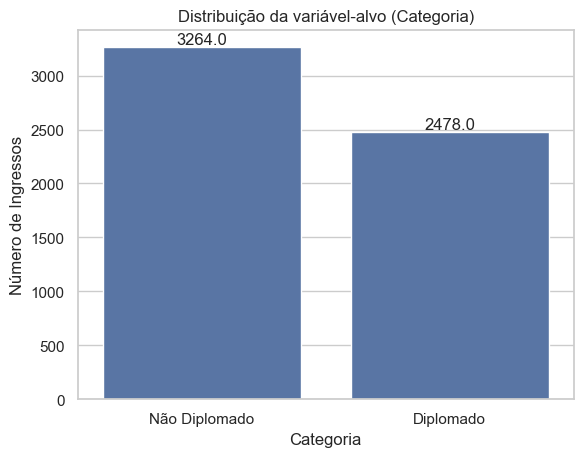

In [132]:
# Gráfico de barras
sns.set(style="whitegrid")
ax = sns.countplot(x="Categoria", data=dt)
ax.set_title("Distribuição da variável-alvo (Categoria)")
ax.set_xlabel("Categoria")
ax.set_ylabel("Número de Ingressos")

# Mostrar valores em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom")

plt.show()

Globalmente, sem olhar para outros campos, a distribuição da variável Categoria apresenta um desbalanceamento moderado, com 56,8% de estudantes não diplomados e 43,2% diplomados. A razão entre categorias é de aproximadamente 1.3:1, valor que não caracteriza um desbalanceamento severo, sendo aceitável para análises estatísticas. Este desbalanceamento pode ser corrigido utilizando o SMOTE, pois gera registo similar ao conjunto de dados originais. Oversampling não é adequado aqui pois vai adulterar o balanço de outros dados existentes e undersampling vai-se perder dados valiosos.

#### Parte 2 — Análise exploratória
1. Selecione três variáveis (pelo menos uma numérica e uma categórica) e analise as suas
distribuições, procurando identificar padrões ou comportamentos relevantes.

Serão escolhidas as variáveis "Nota ingresso", "Idade no ingresso", e "Estado Civil (desc)".

In [133]:
dt2 = dt[["Estado civil (desc)", "Nota ingresso", "Idade no ingresso"]]
dt2

,Estado civil (desc),Nota ingresso,Idade no ingresso
0,Solteiro(a),127.3,20.0
1,Solteiro(a),142.5,19.0
2,Solteiro(a),124.8,19.0
3,Solteiro(a),119.6,20.0
4,Casado(a) com registo,141.5,45.0
...,...,...,...
5737,Solteiro(a),119.0,18.0
5738,Solteiro(a),116.0,20.0
5739,Solteiro(a),149.5,30.0
5740,Solteiro(a),153.8,20.0


In [134]:
dt2_describe = dt2.describe().transpose()
dt2_describe["cv"] = dt2_describe["std"]/dt2_describe["mean"]
dt2_describe

,count,mean,std,min,25%,50%,75%,max,cv
Nota ingresso,5674.0,126.764406,14.679133,45.2,117.4,125.7,134.8,190.0,0.115799
Idade no ingresso,5691.0,23.194166,7.313257,17.0,19.0,20.0,25.0,61.0,0.315306


As idades variam entre 17 e 61 anos, com uma média de 23. As notas de admissão variam entre 45.2 e 190, com uma média de 126.8. O coeficiente de variação apresenta um valor baixo para a nota de ingresso e a mediana corresponde a 125.7, que está muito próxima da média. Isto demonstra baixa variabilidade, seguindo uma distribuição homogénea. No caso da idade no ingresso existe heterogeneidade, uma vez que o coeficiente de variancia é um quanto elevado, nos 31.5%. É de notar que existe uma cauda longa direita, uma vez que 75% dos candidatos são menores de 25, sendo os restantes 25% representantes de todo o conjunto à direita.

Text(0.5, 1.0, 'Contagem de estados civil por notas de admissão')

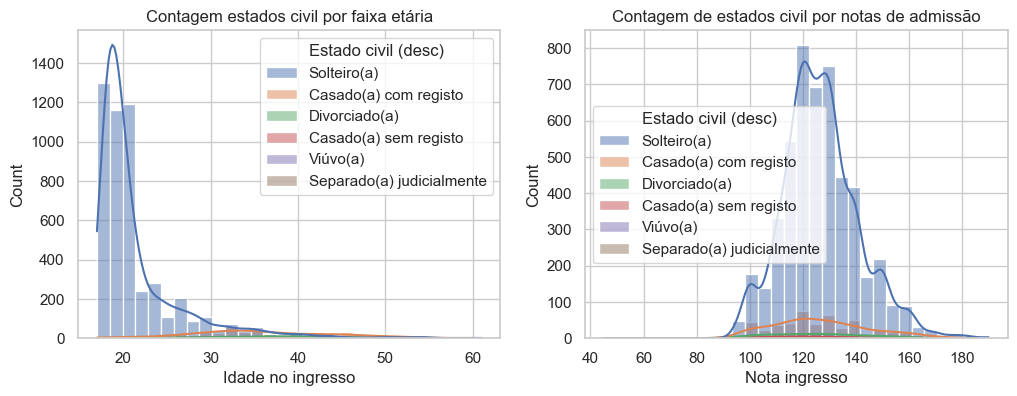

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(x='Idade no ingresso', hue='Estado civil (desc)', data=dt2, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Contagem estados civil por faixa etária")

sns.histplot(x='Nota ingresso', hue='Estado civil (desc)', data=dt2, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Contagem de estados civil por notas de admissão")

Text(0.5, 1.0, 'Relação de Notas e Idade de ingresso, pelo Estado Civil')

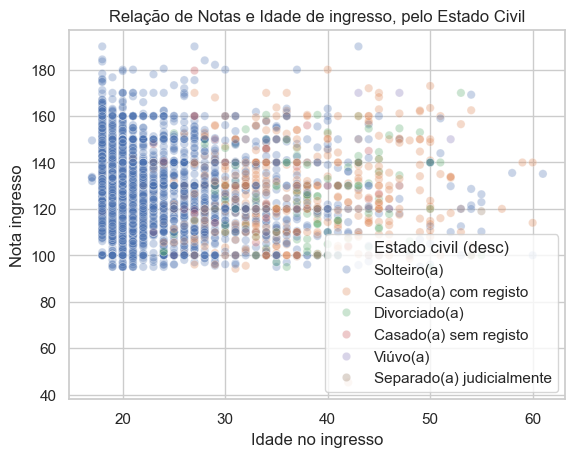

In [136]:
sns.scatterplot(dt2, x='Idade no ingresso', y='Nota ingresso', hue="Estado civil (desc)", alpha=0.3)
plt.title("Relação de Notas e Idade de ingresso, pelo Estado Civil")

**R:** Maior parte do alunos registados são Solteiros, e menores de 30 anos. Existe um ligeiro crescimento proporcional de casados e divorciados entre os 30 e 40 anos seguindo a mesma curva que solteiros. Existem registos de apenas solteiros até aos 22 anos. A partir dos 40 anos os alunos são predominantemente casados ou divorciados, havendo uma divergencia do estado civil consoante a faixa etária. A nível de notas são apenas admitidos alunos com notas superior a 95, no entanto existe um outlier com uma nota de 45.2. As notas de admissão tendem a descer quanto maior for a idade. Existe uma distribuição não uniforme/monotónica nas notas de admissão com *local minimums* em notas com meio valor (105, 125 e 145), possivel que seja devido a efeitos discretos no processo de avaliação, (por exemplo, arredondamentos na nota). Este comportamento também se observa oscilações com *local minimums* no número de solteiros admitidos entre várias faixas etárias, dos 17 aos 35 anos.

2. Analise a relação entre essas variáveis e a variável Categoria, dizendo se existem diferenças visíveis entre estudantes Diplomados e Não Diplomados.

In [137]:
dt3_mask = dt["Categoria"] == "Diplomado"
dt3_diplomados = dt[dt3_mask][["Nota ingresso", "Idade no ingresso", "Estado civil (desc)"]]
dt3_nao_diplomados = dt[~dt3_mask][["Nota ingresso", "Idade no ingresso", "Estado civil (desc)"]]

print("Diplomados:", dt3_diplomados.shape)

print("Não Diplomados:", dt3_nao_diplomados.shape)

Diplomados: (2478, 3)
Não Diplomados: (3264, 3)


In [138]:
dt3_diplomados_describe = dt3_diplomados.describe().transpose()
dt3_nao_diplomados_describe = dt3_nao_diplomados.describe().transpose()
dt3_diplomados_describe["cv"] = dt3_diplomados_describe["std"]/dt3_diplomados_describe["mean"]
dt3_nao_diplomados_describe["cv"] = dt3_nao_diplomados_describe["std"]/dt3_nao_diplomados_describe["mean"]
display(dt3_diplomados_describe)
display(dt3_nao_diplomados_describe)

,count,mean,std,min,25%,50%,75%,max,cv
Nota ingresso,2465.0,128.502803,14.229810,95.0,119.1,127.0,136.3,190.0,0.110735
Idade no ingresso,2459.0,21.688491,6.375087,17.0,18.0,19.0,21.0,60.0,0.293939


,count,mean,std,min,25%,50%,75%,max,cv
Nota ingresso,3209.0,125.429053,14.880027,45.2,116.1,124.0,133.8,190.0,0.118633
Idade no ingresso,3232.0,24.339728,7.760916,17.0,19.0,21.0,28.0,61.0,0.318858


A média de idades de diplomados é por volta dos 22 anos com uma nota de ingresso de aproximadamente 128.5. Para os não diplomados a idade média é 24 anos, com uma média de 125.4. O desvio padrão, mediana e coeficiente de variancia são muito similares comparados com conjunto original, no entanto existe um ligeiro aumento da idade para não diplomados. Diplomados apresentam uma nota minima de ingresso de 95 enquanto os não diplomados de 45.2, que corresponde ao outlier. Este outlier distorce os dados como tal deverá ter de ser excluido, uma vez que a nota de ingresso não é aceitável.

In [139]:
pp = sns.pairplot(dt3_diplomados,
    hue="Estado civil (desc)",
    plot_kws=dict(alpha=0.3), )
pp.fig.suptitle("Relação de Idade e Nota de ingresso por estado civil (Diplomados)")

plt.savefig('fig1.jpg')
plt.close()

pp = sns.pairplot(dt3_nao_diplomados,
    hue="Estado civil (desc)",
    plot_kws=dict(alpha=0.3))
pp.fig.suptitle("Relação de Idade e Nota de ingresso por estado civil (Não diplomados)")

plt.savefig('fig2.jpg')
plt.close()

ts = int(time.time() * 1000)
display(HTML(f"<table><tr><td><img src='fig1.jpg?{ts}'></td><td><img src='fig2.jpg?{ts}'></td></tr></table>"))

,


Text(0.5, 1.0, 'Contagem de estados civil por notas de admissão (Não diplomados)')

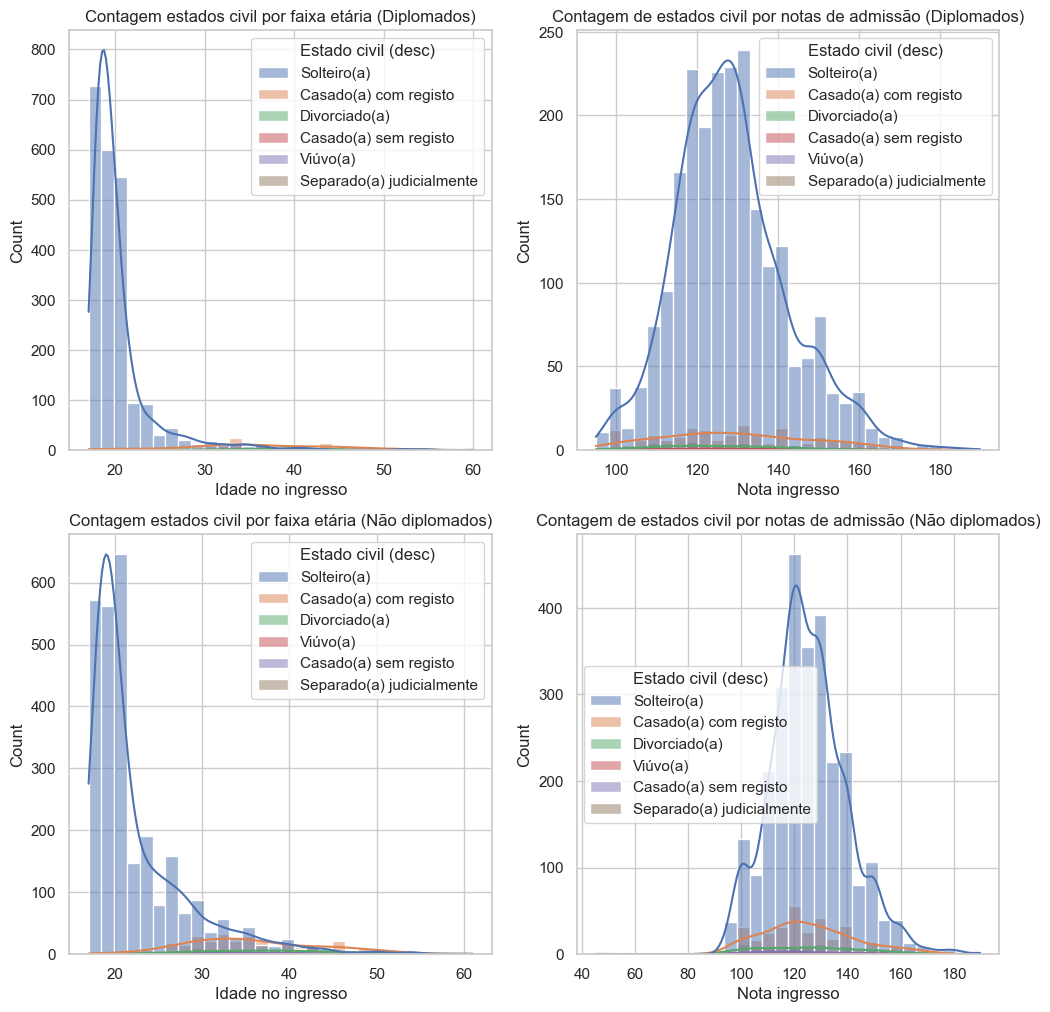

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

sns.histplot(x='Idade no ingresso', hue='Estado civil (desc)', data=dt3_diplomados, bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Contagem estados civil por faixa etária (Diplomados)")

sns.histplot(x='Nota ingresso', hue='Estado civil (desc)', data=dt3_diplomados, bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Contagem de estados civil por notas de admissão (Diplomados)")

sns.histplot(x='Idade no ingresso', hue='Estado civil (desc)', data=dt3_nao_diplomados, bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Contagem estados civil por faixa etária (Não diplomados)")

sns.histplot(x='Nota ingresso', hue='Estado civil (desc)', data=dt3_nao_diplomados, bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Contagem de estados civil por notas de admissão (Não diplomados)")

Existem algumas diferenças entre diplomados e não diplomados. Nas idades de ingresso não se notam os *local minimums* para diplomados. Existem mais casos de casados com registo em não diplomados que diplomados. A distribuição de notas em diplomados é maior que não diplomados. Contudo, estes histogramas são um quanto inconclusivos, havendo a necessidade de aumentar a granularidade para compreender o conteúdo.  Nos graficos seguintes são comparados cada estados civil entre diplomados e não diplomados.

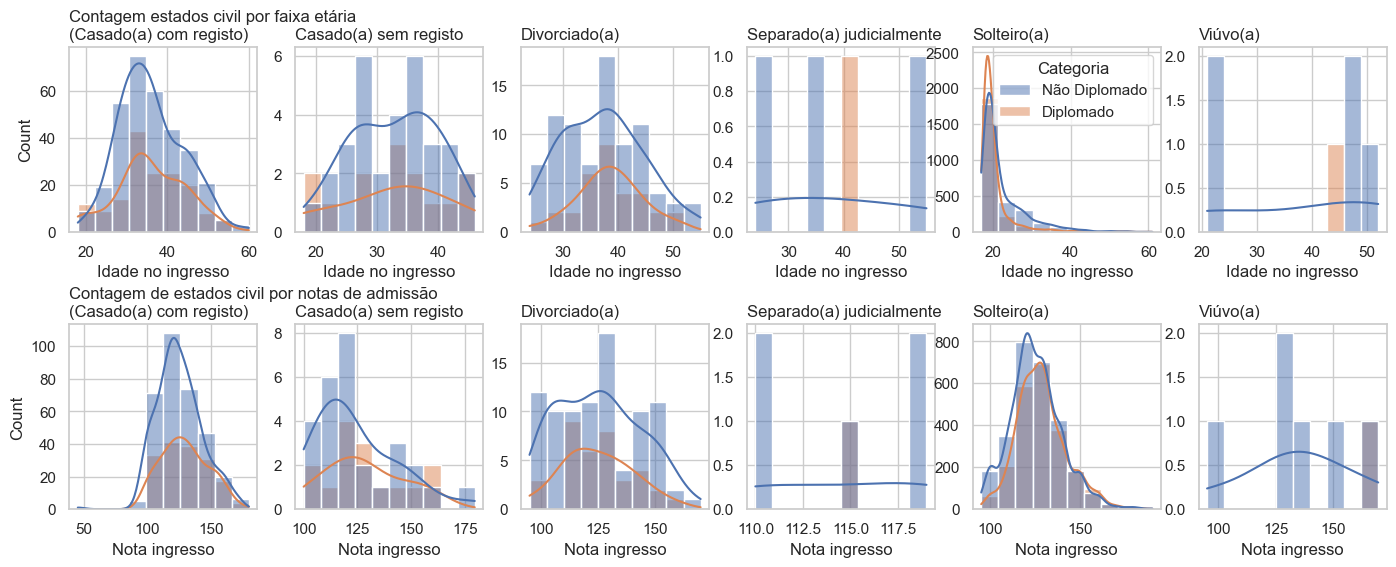

In [141]:
dt4 = dt.groupby("Estado civil (desc)")[["Nota ingresso", "Idade no ingresso", "Categoria"]]
fig, axes = plt.subplots(2, 6, figsize=(17, 6))
i = 0
plt.subplots_adjust(hspace = 0.5)
categoria_order = dt["Categoria"].unique() # Para garantir consistencia das cores sempre que se usa apenas uma legenda para todos os graficos.

for key, subset in dt4:
    hp = sns.histplot(x='Idade no ingresso', hue='Categoria', hue_order=categoria_order, bins=10, data=subset,  kde=True, ax=axes[0, i])
    hp.get_legend().set_visible(i == 4)

    if i == 0:
        hp.set_title(f"Contagem estados civil por faixa etária \n({key})", loc="left")
    else:
       hp.set_title(key, loc="left")
    if (i > 0):
        hp.set_ylabel("")

    hp = sns.histplot(x='Nota ingresso', hue='Categoria', hue_order=categoria_order, bins=10, data=subset, kde=True, ax=axes[1, i])
    hp.get_legend().set_visible(False)
    if i == 0:
        hp.set_title(f"Contagem de estados civil por notas de admissão\n({key})", loc="left")
    else:
        hp.set_title(key, loc="left")
    if i > 0:
        hp.set_ylabel("")
    i += 1

Aqui a informação torna-se mais clara. A distribuição de idades e notas de ingresso em `Solteiros` e `Casado(a) com registo` formam curvas similares para ambas categorias. Existe mais probabilidade de sucesso de conclusão se o aluno for solteiro e mais jovem. `Separado(a) judicialmente`, e `Viúvo(a)` não possuem uma população suficientemente grande para ter uma análise com resultados conclusivos, no entanto existe uma maior concentração de viúvos maiores de 40 anos. As notas de `Separado(a) judicialmente` são mais mediocres que `Viúvo(a)`. Maior parte dos alunos são jovens têm idade menor de 25 anos, no entanto há um crescimento de ingressos em casados maiores de 30 anos. `Casado(a) sem registo` seguem uma distribuição dissimétrica na idade de ingresso, com picos pelos 28/29 anos e os 38 anos, com notas mais dominantes entre os 110 e 120. `Divorciado(a)' também seguem uma distribuição assimétrica com pico nos 38 anos com notas de 130. Aproximadamente metade é diplomado.

3. Alguma das variáveis parece(m) ser mais promissoras para distinguir os dois grupos?

Sim. O estado civil `Casado(a) com registo`, e a idade de ingresso mais tardia apresentam ser possivel indicadores para não diplomados. Possivelmente poderão ser usados para prever maior probabilidade de o aluno demorar ou desistir do curso.

#### Parte 3 — Qualidade dos dados

Identifique e trate valores em falta, possíveis inconsistências, outliers em variáveis numéricas, ou outros aspetos considerados relevantes. Para cada problema identificado justifique a estratégia de tratamento adotada, explicando, sempre que possível, porque é a decisão adequado no contexto.

In [142]:
print("Valores nulos ou n/a:")
print("---------------------")
dt.isna().sum()

Valores nulos ou n/a:
---------------------


Sexo (M/F)                           0
Estado civil (desc)                  0
Ordem de ingresso                    0
Curso (desc)                         0
Deslocado (S/N)                      0
Nacionalidade (desc)                 0
Habilitação literária mãe (desc)    20
Situação profissional mãe (desc)     0
Situação profissional pai (desc)     0
Nota ingresso                       68
Bolseiro                             0
Idade no ingresso                   51
Categoria                            0
dtype: int64

Nota-se que a `Habilitação literária mãe (desc)`, `Nota ingresso` e `Idade no ingresso` possuem valores n/a ou nulos. estes devem ser imputados utilizando o SimpleImputer. Para colunas numéricas usa-se a mediana, e na categórica usa-se a categoria mais comum.

In [143]:
medianImputer = SimpleImputer(strategy='median')
commonImputer = SimpleImputer(strategy='most_frequent')

dt_num = dt.select_dtypes(include='number')
dt_num_imp = pd.DataFrame(
    medianImputer.fit_transform(dt_num),
    columns=dt_num.columns,
    index=dt.index)

dt_hab_mae = dt[['Habilitação literária mãe (desc)']]
dt_hab_mae_imp = pd.DataFrame(
    commonImputer.fit_transform(dt_hab_mae),
    columns=dt_hab_mae.columns,
    index=dt.index)

dt[dt_num_imp.columns] = dt_num_imp
dt[dt_hab_mae_imp.columns] = dt_hab_mae_imp
dt.isna().sum()

Sexo (M/F)                          0
Estado civil (desc)                 0
Ordem de ingresso                   0
Curso (desc)                        0
Deslocado (S/N)                     0
Nacionalidade (desc)                0
Habilitação literária mãe (desc)    0
Situação profissional mãe (desc)    0
Situação profissional pai (desc)    0
Nota ingresso                       0
Bolseiro                            0
Idade no ingresso                   0
Categoria                           0
dtype: int64

Em seguida verifica-se os valores de as notas de ingresso. Quaisquer notas abaixo dos 95 ou maiores que 200 não devem ser consideradas como válidas.

In [144]:
dt[dt["Nota ingresso"] < 95]

,Sexo (M/F),Estado civil (desc),Ordem de ingresso,Curso (desc),Deslocado (S/N),Nacionalidade (desc),Habilitação literária mãe (desc),Situação profissional mãe (desc),Situação profissional pai (desc),Nota ingresso,Bolseiro,Idade no ingresso,Categoria
716,M,Casado(a) com registo,1.0,Administração de Publicidade e Marketing,N,Portuguesa,Desconhecido,Desconhecida /Não Tem,Desconhecida /Não Tem,94.2,0.0,31.0,Não Diplomado
4337,M,Casado(a) com registo,1.0,Gestão,N,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Reformado/a,Reformado/a,45.2,0.0,42.0,Não Diplomado


In [145]:
dt[dt["Nota ingresso"] > 200]

,Sexo (M/F),Estado civil (desc),Ordem de ingresso,Curso (desc),Deslocado (S/N),Nacionalidade (desc),Habilitação literária mãe (desc),Situação profissional mãe (desc),Situação profissional pai (desc),Nota ingresso,Bolseiro,Idade no ingresso,Categoria


Como já analisado anteriormente, existe um outlier com uma nota de ingresso de 45.2. No entanto existe mais uma nota de 94.2, totalizando 2 outliers. Visto serem valores não aceitáveis para ingresso podemos as excluir.

In [146]:
dt = dt[dt["Nota ingresso"] >= 95]
dt.shape

(5740, 13)

É de notar que existe muita fragmentação na coluna `Habilitação literária mãe (desc)`. Algumas destas classificações podem ser agregadas, por exemplo, pela equivalência ao Quadro europeu de Qualificações (QEQ), ou ciclo de escolaridade obrigatória por exemplo:

- Agregar `Sem escolaridade obrigatória`:
  - `Sabe ler sem possuir o 4º ano de escolaridade`
  - `Não sabe ler nem escrever`

- Em `Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.` podemos agregar:
  - `7º Ano de Escolaridade`
  - `9º Ano de Escolaridade - Não Concluído`
  - `7º Ano (Antigo)`
  - `8º Ano de Escolaridade`

- Em `Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.` podemos agregar:
  - `Curso Geral de Administração e Comércio`
  - `Outro - 11º Ano de Escolaridade`
  - `11º Ano de Escolaridade - Não Concluído`
  - `10º Ano de Escolaridade`
  - `12º Ano de Escolaridade - Não Concluído`
  - `Curso Geral de Comércio`
  - `Curso Complementar Liceal - Não Concluído`
  - `2º Ano Curso Complementar Liceal`

- Em `Ensino Secundário (12º Ano) ou Equiv.` podemos agregar:
  - `Curso Técnico-Profissional`
  - `Curso Complementar Liceal`
  - `2ª Ciclo do Curso Geral Liceal`
  - `Complementar de Contabilidade e Administração`

- Agregar em `Cursos superiores ou de especialização (QEQ Nível 5)`:
  - `Curso de Especialização Tecnológica`
  - `Curso Técnico Superior Profissional`
  - `Curso de Estudos Superiores Especializados`
  - `Frequência do Ensino Superior`

- Em `Ensino Superior - Licenciatura` podemos agregar:
  - `Ensino Superior - Licenciatura (1º ciclo)`

- Em `Ensino Superior - Mestrado` podemos agregar:
  - `Ensino Superior - Mestrado (2º ciclo)`

- Em `Ensino Superior - Doutoramento` podemos agregar:
  - `Ensino Superior - Doutoramento (3º ciclo)`


In [147]:
col_hab = "Habilitação literária mãe (desc)"
habilitacoes = {
    "Sem escolaridade obrigatória": [
        "Sabe ler sem possuir o 4º ano de escolaridade",
        "Não sabe ler nem escrever"
    ],
    "Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.": [
        "7º Ano de Escolaridade",
        "9º Ano de Escolaridade - Não Concluído",
        "7º Ano (Antigo)", "8º Ano de Escolaridade"
    ],
    "Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.": [
        "Curso Geral de Administração e Comércio",
        "Outro - 11º Ano de Escolaridade",
        "11º Ano de Escolaridade - Não Concluído",
        "10º Ano de Escolaridade",
        "12º Ano de Escolaridade - Não Concluído",
        "Curso Geral de Comércio",
        "Curso Complementar Liceal - Não Concluído"
    ],
    "Ensino Secundário (12º Ano) ou Equiv.": [
        'Curso Técnico-Profissional',
        'Curso Complementar Liceal',
        '2ª Ciclo do Curso Geral Liceal',
        'Complementar de Contabilidade e Administração',
        '2º Ano Curso Complementar Liceal'
    ],

    "Cursos superiores ou de especialização (QEQ Nível 5)": [
        "Curso de Especialização Tecnológica",
        "Curso Técnico Superior Profissional",
        "Curso de Estudos Superiores Especializados",
        "Frequência do Ensino Superior",
    ],
    
    "Ensino Superior - Licenciatura":[
        "Ensino Superior - Licenciatura (1º ciclo)"
    ],

    "Ensino Superior - Mestrado": [
        "Ensino Superior - Mestrado (2º ciclo)"
    ],

    "Ensino Superior - Doutoramento": [
        "Ensino Superior - Doutoramento (3º ciclo)"
    ]
}

for key, items in habilitacoes.items():
    dt.loc[dt[col_hab].isin(items), col_hab] = key

dt[col_hab].unique()

array(['Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.',
       'Ensino Superior - Licenciatura',
       'Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.',
       'Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.',
       'Ensino Secundário (12º Ano) ou Equiv.',
       'Ensino Superior - Doutoramento', 'Ensino Superior - Mestrado',
       'Ensino Superior - Bacharelato', 'Desconhecido',
       'Cursos superiores ou de especialização (QEQ Nível 5)',
       'Sem escolaridade obrigatória'], dtype=object)

#### Parte 4 — Preparação dos dados
1. Prepare o conjunto de dados para uma futura fase de modelação: converta variáveis categóricas
em formato numérico; aplique técnicas de normalização ou padronização a variáveis numéricas.  
Justifique as escolhas efetuadas.

Para preparação do conjunto de dados serão feitos os seguintes passos:
- As seguintes colunas serão codificadas através de mapeamento directo, através de dicionários e listas *hard-coded*:
  - Define-se a criação de uma nova coluna `Habilitação literária mãe (classe)` usando mapeamento directo.
    - Para garantir cardinalidade pelo gau de escolaridade, é usada uma lista ordenada com as novas habilitações. A lista corresponde ao grau de qualificação de `0`, `Desconhecido`, `1` `Sem escolaridade obrigatória`, até `10` `Ensino Superior - Doutoramento`.
  - Serão criadas duas novas colunas, a de texto `Escola (desc)` e a numérica `Escola (classe)`, através de mapeamento directo, que indicam a escola que oferece o curso. Isto permite classificar os dados do dataset por escola.
- As seguintes colunas terão uma coluna numérica equivalente codificada através de `LabelEncoder`, visto serem classificações com um grande número de entradas:
  - `Curso` - `Curso (classe)`,
  - `Estado civil (desc)` - `Estado civil (classe)`,
  - `Situação profissional mãe (desc)` - `Situação profissional mãe (classe)`,
  - `Situação profissional pai (desc)` - `Situação profissional pai (classe)`
- As seguintes colunas terão uma coluna binária, codificada através de `OneHotEncoder`, uma vez que apenas tem dois valores possíveis.
  - `Categoria` - `Categoria_Diplomado`
  - `Sexo (M/F)` - `Sexo_Masculino`
  - `Deslocado (S/N)` - `Deslocado`
- É criada uma coluna numérica `Nr. anos de curso` que indica quantos anos o curso tem (4 para Enfermagem, 3 para os restantes).
- Serão criadas as seguintes colunas binárias por ventura a obter informação geodemográfica e outros possíveis indicadores do dataset 
  - É criada uma coluna binária `Família de risco` para alunos cujo ambos os pais não possuam uma forma de remuneração estável. Pelo menos um parente deve ter `Trabalhador(a) por Conta Própria como Isolado`, `Trabalhador(a) por Conta Própria como empregador`, `Trabalhador(a) por Conta de Outrém`, `Serviço Militar`.
  - Colunas de indicação geodemográfica:
    - `Origem de país do acordo ortográfico` para alunos de nacionalidade `Portuguesa`, `Brasileira`, `Guineense`, `Santomense`, `Caboverdeana`, `Angolana` e `Moçambicana`.
    - `Origem de país da UE` para alunos de nacionalidade `Portuguesa`, `Espanhola`, `Romena`, `Italiana`, `Alemã`, `Holandesa`, `Bulgara` e `Lituana`.
    - `Origem de país do continente americano` para alunos de nacionalidade `Brasileira`, `Mexicana`, `Cubana` e `Uruguai`
    - `Origem de país estrangeiro` com nacionalidade não portuguesa.
    - `Origem de país do continente euroásiatico` com nacionalidade na euroásia, como `Portuguesa`, `Espanhola`, `Ucraniana`, `Romena`, `Italiana`, `Moldova (República de)`, `Alemã`, `Russa`, `Holandesa`, `Turca`, `Bulgara`, `Inglesa`, e `Lituana`.
    - `Origem de país do continente africano` com nacionalidade na europa e ásia, como `Guineense`, `Santomense`, `Caboverdeana`, `Angolana` e `Moçambicana`.
- Aplicadas as seguintes normalizações:
  - `nota_ingresso_norm`: Nota normalizada utilizando a transformação `StandardScaler`, para comparação relativa entre o desempenho das notas
  - `idade_ingresso_norm`: Idade normalizada utilizando a transformação `RobustScaler`, pois quanto mais velhos mais se tornam outliers.

In [148]:
dt_processed = dt.copy() # Para dados transformados

In [149]:
# Habilitações Literárias
ordered_hab = [
    'Desconhecido',
    'Sem escolaridade obrigatória',
    'Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.',
    'Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.',
    'Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.',
    'Ensino Secundário (12º Ano) ou Equiv.',
    'Cursos superiores ou de especialização (QEQ Nível 5)',
    'Ensino Superior - Licenciatura',
    'Ensino Superior - Bacharelato',
    'Ensino Superior - Mestrado',
    'Ensino Superior - Doutoramento',
]

col_hab_desc = "Habilitação literária mãe (desc)"
col_hab_class = "Habilitação literária mãe (classe)"

for i, habilitacao in enumerate(ordered_hab):
    mask = dt_processed[col_hab_desc] == habilitacao
    dt_processed.loc[mask, col_hab_class] = i

dt_processed[[col_hab_class, col_hab_desc]].value_counts().sort_index()

Habilitação literária mãe (classe)  Habilitação literária mãe (desc)                    
0.0                                 Desconhecido                                             110
1.0                                 Sem escolaridade obrigatória                              10
2.0                                 Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.            1587
3.0                                 Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.          937
4.0                                 Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.       1310
5.0                                 Ensino Secundário (12º Ano) ou Equiv.                   1195
6.0                                 Cursos superiores ou de especialização (QEQ Nível 5)      37
7.0                                 Ensino Superior - Licenciatura                           382
8.0                                 Ensino Superior - Bacharelato                             95
9.0                                 En

In [150]:
# Escolas
escolas = {
    'ESS - Escola Superior de Saúde': [
        'Enfermagem',
        'Higiene Oral',
    ],
    'ESTGD - Escola Superior de Tecnologias, Gestão e Design': [
        'Gestão',
        'Gestão (pós-laboral)',
        'Administração de Publicidade e Marketing',
        'Design de Animação e Multimédia',
        'Engenharia Informática',
        'Design de Comunicação',
        'Tecnologias de Produção de Biocombustíveis',
    ],
    'ESECS - Escola Superior de Educação e Ciencias Sociais': [
        'Turismo',
        'Jornalismo e Comunicação',
        'Serviço Social',
        'Serviço Social (pós-laboral)',
        'Educação Básica',
    ],
    'ESBE - Escola Superior de Biociências de Elvas': [
        'Agronomia',
        'Equinicultura',
        'Enfermagem Veterinária',
    ],
}

col_escola_desc = "Escola (desc)"
col_escola_class = "Escola (classe)"
col_curso_desc = "Curso (desc)"

for i, (escola, cursos) in enumerate(escolas.items()):
    curso_mask = dt_processed[col_curso_desc].isin(cursos)
    dt_processed.loc[curso_mask, col_escola_desc] = escola
    dt_processed.loc[curso_mask, col_escola_class] = i

dt_processed[[col_escola_class, col_escola_desc]].value_counts().sort_index()

Escola (classe)  Escola (desc)                                          
0.0              ESS - Escola Superior de Saúde                             1041
1.0              ESTGD - Escola Superior de Tecnologias, Gestão e Design    2146
2.0              ESECS - Escola Superior de Educação e Ciencias Sociais     1698
3.0              ESBE - Escola Superior de Biociências de Elvas              855
Name: count, dtype: int64

In [151]:
# Curso (desc), Estado civil (desc), Situação profissional mãe (desc), Situação profissional pai (desc)
query_cols = [
    'Curso (desc)',
    'Estado civil (desc)',
    'Situação profissional mãe (desc)',
    'Situação profissional pai (desc)']
novas_cols = [
    'Curso (classe)',
    'Estado civil (classe)',
    'Situação profissional mãe (classe)',
    'Situação profissional pai (classe)']

for col, new_col in zip(query_cols, novas_cols):
    le = LabelEncoder()
    dt_processed[new_col] = le.fit_transform(dt_processed[col])
    display(dt_processed.loc[:, [col, new_col]].value_counts().sort_index())

Curso (desc)                                Curso (classe)
Administração de Publicidade e Marketing    0                 360
Agronomia                                   1                 273
Design de Animação e Multimédia             2                 319
Design de Comunicação                       3                 277
Educação Básica                             4                 230
Enfermagem                                  5                 928
Enfermagem Veterinária                      6                 410
Engenharia Informática                      7                 234
Equinicultura                               8                 172
Gestão                                      9                 585
Gestão (pós-laboral)                        10                354
Higiene Oral                                11                113
Jornalismo e Comunicação                    12                422
Serviço Social                              13                462
Serviço Social (p

Estado civil (desc)        Estado civil (classe)
Casado(a) com registo      0                         508
Casado(a) sem registo      1                          47
Divorciado(a)              2                         128
Separado(a) judicialmente  3                           6
Solteiro(a)                4                        5044
Viúvo(a)                   5                           7
Name: count, dtype: int64

Situação profissional mãe (desc)                  Situação profissional mãe (classe)
Aluno/a                                           0                                        1
Desconhecida /Não Tem                             1                                      143
Desempregado/a                                    2                                      463
Domestico/a                                       3                                      642
Outra Situação (Falecido/a)                       4                                      134
Reformado/a                                       5                                      547
Trabalhador(a) Familiar não remunerado            6                                        6
Trabalhador(a) por Conta Própria como Isolado     7                                      235
Trabalhador(a) por Conta Própria como empregador  8                                      234
Trabalhador(a) por Conta de Outrém                9                           

Situação profissional pai (desc)                  Situação profissional pai (classe)
Aluno/a                                           0                                        2
Desconhecida /Não Tem                             1                                      120
Desempregado/a                                    2                                      359
Domestico/a                                       3                                        3
Outra Situação (Falecido/a)                       4                                      242
Reformado/a                                       5                                      777
Serviço Militar                                   6                                       20
Trabalhador(a) Familiar não remunerado            7                                        2
Trabalhador(a) por Conta Própria como Isolado     8                                      403
Trabalhador(a) por Conta Própria como empregador  9                           

In [152]:
# indicadores binários OneHotEncoder
ohe=OneHotEncoder(sparse_output=False, drop="first")
query_cols = ["Sexo (M/F)", "Deslocado (S/N)", "Categoria"]
new_vals = ohe.fit_transform(dt_processed[query_cols])
new_cols = ohe.get_feature_names_out()

dt_ohe = pd.DataFrame(new_vals, columns = new_cols, index = dt_processed.index)
dt_processed = pd.concat([dt_processed, dt_ohe], axis=1)

for old, new in zip(query_cols, new_cols):
    display(dt_processed.loc[:, [old, new]].value_counts().sort_index())

Sexo (M/F)  Sexo (M/F)_M
F           0.0             3628
M           1.0             2112
Name: count, dtype: int64

Deslocado (S/N)  Deslocado (S/N)_S
N                0.0                  2747
S                1.0                  2993
Name: count, dtype: int64

Categoria      Categoria_Não Diplomado
Diplomado      0.0                        2478
Não Diplomado  1.0                        3262
Name: count, dtype: int64

In [153]:
# indicadores numéricos
dt_processed['Nr. anos de curso'] = (dt_processed['Curso (classe)'] == 5).astype(int) + 3
dt_processed['Nr. anos de curso'].value_counts()

Nr. anos de curso
3    4812
4     928
Name: count, dtype: int64

In [154]:
# indicadores binários (manuais)
rendimento_estavel = [
    "Trabalhador(a) por Conta Própria como Isolado",
    "Trabalhador(a) por Conta Própria como Empregador",
    "Trabalhador(a) por Conta de Outrém",
    "Serviço Militar"
]

dt_processed['Família de risco'] = (
    ~dt_processed['Situação profissional mãe (desc)'].isin(rendimento_estavel) &
    ~dt_processed['Situação profissional pai (desc)'].isin(rendimento_estavel)
).astype(int)

origem_acordo = ["Portuguesa", "Brasileira", "Guineense", "Santomense", "Caboverdeana", "Angolana", "Moçambicana"]
origem_ue = ["Portuguesa", "Espanhola", "Romena", "Italiana", "Alemã", "Holandesa", "Bulgara", "Lituana"]
origem_america = ["Brasileira", "Mexicana", "Cubana", "Uruguai"]
origem_euroasiatica = ["Portuguesa", "Espanhola", "Ucraniana", "Romena", "Italiana",
                       "Moldova (República de)", "Alemã", "Russa", "Holandesa", "Turca", "Bulgara",
                       "Inglesa", "Lituana"]
origem_africana = ["Guineense", "Santomense", "Caboverdeana", "Angolana", "Moçambicana"]

dt_processed['Origem de país de acordo ortográfico'] = dt_processed['Nacionalidade (desc)'].isin(origem_acordo).astype(int)
dt_processed['Origem de país da UE'] = dt_processed['Nacionalidade (desc)'].isin(origem_ue).astype(int)
dt_processed['Origem de país do continente americano'] = dt_processed['Nacionalidade (desc)'].isin(origem_america).astype(int)
dt_processed['Origem de país estrangeiro'] = (dt_processed['Nacionalidade (desc)'] != "Portuguesa").astype(int)
dt_processed['Origem de país do continente euroásiatico'] = dt_processed['Nacionalidade (desc)'].isin(origem_euroasiatica).astype(int)
dt_processed['Origem de país do continente africano'] = dt_processed['Nacionalidade (desc)'].isin(origem_africana).astype(int)

display(dt_processed[['Origem de país de acordo ortográfico']].value_counts())
display(dt_processed[['Origem de país da UE']].value_counts())
display(dt_processed[['Origem de país do continente americano']].value_counts())
display(dt_processed[['Origem de país estrangeiro']].value_counts())
display(dt_processed[['Origem de país do continente euroásiatico']].value_counts())
display(dt_processed[['Origem de país do continente africano']].value_counts())

Origem de país de acordo ortográfico
1                                       5696
0                                         44
Name: count, dtype: int64

Origem de país da UE
1                       5584
0                        156
Name: count, dtype: int64

Origem de país do continente americano
0                                         5668
1                                           72
Name: count, dtype: int64

Origem de país estrangeiro
0                             5556
1                              184
Name: count, dtype: int64

Origem de país do continente euroásiatico
1                                            5596
0                                             144
Name: count, dtype: int64

Origem de país do continente africano
0                                        5668
1                                          72
Name: count, dtype: int64

In [155]:
# Normalização de numéricos
dt_processed['Nota ingresso (Norm)'] = StandardScaler().fit_transform(dt_processed[['Nota ingresso']])
dt_processed['Idade no ingresso (Norm)'] = RobustScaler().fit_transform(dt_processed[['Nota ingresso']])
dt_processed[['Nota ingresso', 'Nota ingresso (Norm)', 'Idade no ingresso', 'Idade no ingresso (Norm)']]

,Nota ingresso,Nota ingresso (Norm),Idade no ingresso,Idade no ingresso (Norm)
0,127.3,0.036317,20.0,0.093390
1,142.5,1.081166,19.0,0.980592
2,124.8,-0.135533,19.0,-0.052532
3,119.6,-0.492982,20.0,-0.356048
4,141.5,1.012426,45.0,0.922224
...,...,...,...,...
5737,119.0,-0.534226,18.0,-0.391070
5738,116.0,-0.740446,20.0,-0.566175
5739,149.5,1.562346,30.0,1.389173
5740,153.8,1.857929,20.0,1.640158


In [156]:
dt_processed.to_csv("dataset_PIAES_reduced_processed.csv")
dt_processed

,Sexo (M/F),Estado civil (desc),Ordem de ingresso,Curso (desc),Deslocado (S/N),Nacionalidade (desc),Habilitação literária mãe (desc),Situação profissional mãe (desc),Situação profissional pai (desc),Nota ingresso,...,Nr. anos de curso,Família de risco,Origem de país de acordo ortográfico,Origem de país da UE,Origem de país do continente americano,Origem de país estrangeiro,Origem de país do continente euroásiatico,Origem de país do continente africano,Nota ingresso (Norm),Idade no ingresso (Norm)
0,M,Solteiro(a),5.0,Design de Animação e Multimédia,S,Portuguesa,Ensino Básico 3º Ciclo (9º/10º/11º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Outra Situação (Falecido/a),127.3,...,3,0,1,1,0,0,1,0,0.036317,0.093390
1,M,Solteiro(a),1.0,Turismo,S,Portuguesa,Ensino Superior - Licenciatura,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,142.5,...,3,0,1,1,0,0,1,0,1.081166,0.980592
2,M,Solteiro(a),5.0,Design de Comunicação,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Desempregado/a,124.8,...,3,0,1,1,0,0,1,0,-0.135533,-0.052532
3,F,Solteiro(a),2.0,Jornalismo e Comunicação,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,119.6,...,3,0,1,1,0,0,1,0,-0.492982,-0.356048
4,F,Casado(a) com registo,1.0,Serviço Social (pós-laboral),N,Portuguesa,Ensino Básico 2º Ciclo (6º/7º/8º Ano) ou Equiv.,Reformado/a,Reformado/a,141.5,...,3,1,1,1,0,0,1,0,1.012426,0.922224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5737,F,Solteiro(a),2.0,Jornalismo e Comunicação,S,Russa,Ensino Secundário (12º Ano) ou Equiv.,Trabalhador(a) por Conta Própria como Isolado,Trabalhador(a) por Conta de Outrém,119.0,...,3,0,0,0,0,1,1,0,-0.534226,-0.391070
5738,F,Solteiro(a),1.0,Enfermagem,N,Portuguesa,Ensino Secundário (12º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,116.0,...,4,0,1,1,0,0,1,0,-0.740446,-0.566175
5739,F,Solteiro(a),1.0,Enfermagem,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Reformado/a,Desempregado/a,149.5,...,4,1,1,1,0,0,1,0,1.562346,1.389173
5740,F,Solteiro(a),1.0,Gestão,S,Portuguesa,Ensino Básico 1º Ciclo (4º/5º Ano) ou Equiv.,Trabalhador(a) por Conta de Outrém,Trabalhador(a) por Conta de Outrém,153.8,...,3,0,1,1,0,0,1,0,1.857929,1.640158


2. Aplique uma técnica de tratamento de dados desbalanceados, comparando a distribuição antes e
depois. Discuta as vantagens e riscos da abordagem escolhida neste problema concreto

Começamos por verificar a frequência relativa dos valores da variável alvo, `Deslocado (S/N)`:

In [157]:
freq = dt["Deslocado (S/N)"].value_counts()
freq_pct = dt["Deslocado (S/N)"].value_counts(normalize=True) * 100

print("Frequências absolutas:")
print(freq)
print("\nFrequências relativas (%):")
print(freq_pct.round(2))
print(f"\nRazão: {freq.iloc[0]/freq.iloc[1]:.{2}}:1")

Frequências absolutas:
Deslocado (S/N)
S    2993
N    2747
Name: count, dtype: int64

Frequências relativas (%):
Deslocado (S/N)
S    52.14
N    47.86
Name: proportion, dtype: float64

Razão: 1.1:1


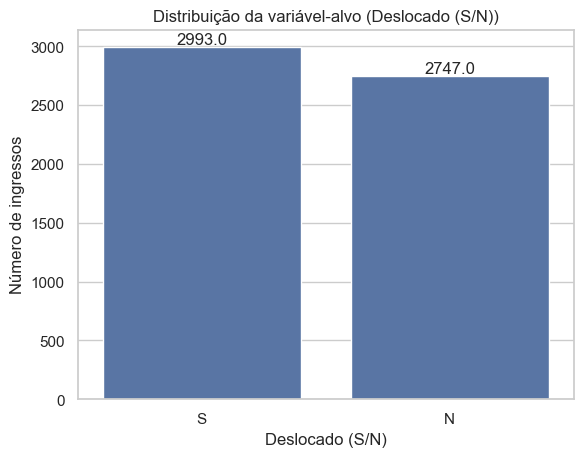

In [158]:
# Gráfico de barras
sns.set(style="whitegrid")
ax = sns.countplot(x="Deslocado (S/N)", data=dt_processed)
ax.set_title("Distribuição da variável-alvo (Deslocado (S/N))")
ax.set_xlabel("Deslocado (S/N)")
ax.set_ylabel("Número de ingressos")

# Mostrar valores em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom")

plt.show()

A distribuição dos dados razão é de aproximadamente 52% para deslocados e 48% de locais, com um rácio de 1.1:1, Apresenta um ligeiro desbalanceamento, sendo aceitável para análises estatísticas. Este desbalanceamento pode ser corrigido utilizando oversampling, uma vez que não impacta muito o conteúdo do dataset, no entanto SMOTE será o mais recomendado. No entanto, o SMOTE só aceita dataframes numéricos. Como tal iremos extrair apenas o subconjunto numérico do dataset. O risco deste modelo é que estaremos a adulterar ligeiramente o conteúdo do dataset e com isso a sua distribuição, ainda assim é melhor que o Undersampling e Oversampling, pois o primeiro destrói dados valiosos e oversampling pode distorcer bastante tanto a distribuição como a influência de alguns campos.

In [184]:
col = "Deslocado (S/N)_S"
dt_numeric = dt_processed.select_dtypes(include="number")
X = dt_numeric.drop(col, axis=1)
y = dt_numeric[col]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nDistribuição após SMOTE:")
print(y_res.value_counts())
print("\nDistribuição após SMOTE (%):")
print((y_res.value_counts(normalize=True) * 100).round(2))


Distribuição após SMOTE:
Deslocado (S/N)_S
1.0    2993
0.0    2993
Name: count, dtype: int64

Distribuição após SMOTE (%):
Deslocado (S/N)_S
1.0    50.0
0.0    50.0
Name: proportion, dtype: float64


C:\Users\migue\AppData\Local\Temp\ipykernel_22440\4003334255.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


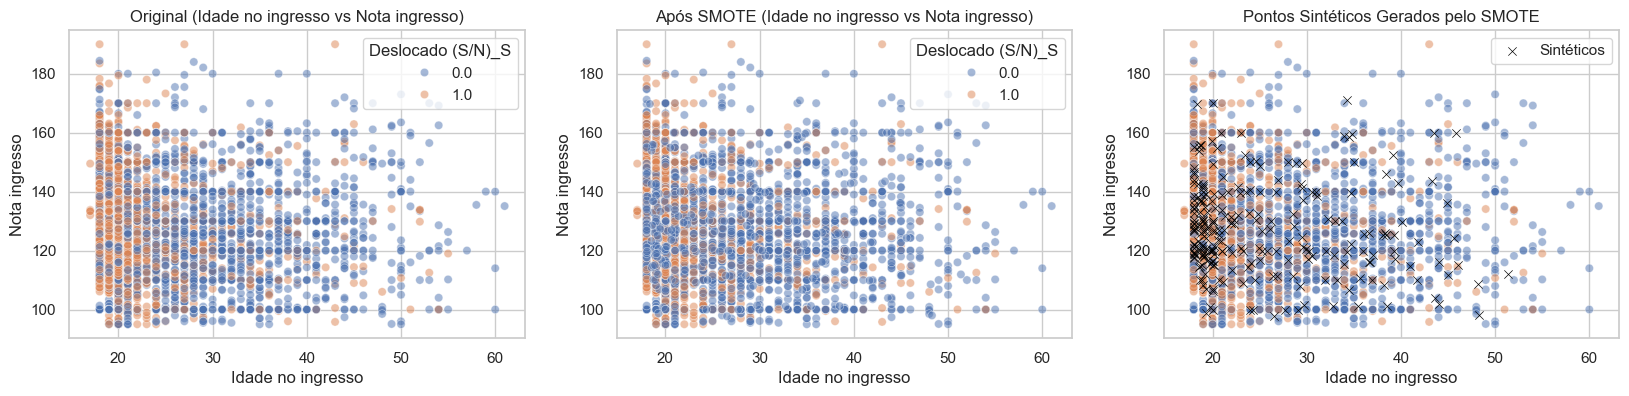

In [191]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# Gráfico original
sp = sns.scatterplot(x=X["Idade no ingresso"], y=X["Nota ingresso"], hue=y, alpha=0.5, ax=axes[0])
sp.set_title("Original (Idade no ingresso vs Nota ingresso)")
sp = sns.scatterplot(x=X["Idade no ingresso"], y=X["Nota ingresso"], hue=y, alpha=0.5, ax=axes[2], legend=False)
sp.set_title("Original (Idade no ingresso vs Nota ingresso)")

# Gráfico após SMOTE
sp = sns.scatterplot(x=X_res["Idade no ingresso"], y=X_res["Nota ingresso"], hue=y_res, alpha=0.5, ax=axes[1])
sp.set_title("Após SMOTE (Idade no ingresso vs Nota ingresso)")


# Sintéticos
n_original = len(X)
X_sint = X_res.iloc[n_original:]
y_sint = y_res.iloc[n_original:]
sp = sns.scatterplot(
    x=X_sint["Idade no ingresso"], y=X_sint["Nota ingresso"],
    color="black", marker="x", label="Sintéticos", ax=axes[2]
)
sp.set_title("Pontos Sintéticos Gerados pelo SMOTE")

fig.show()

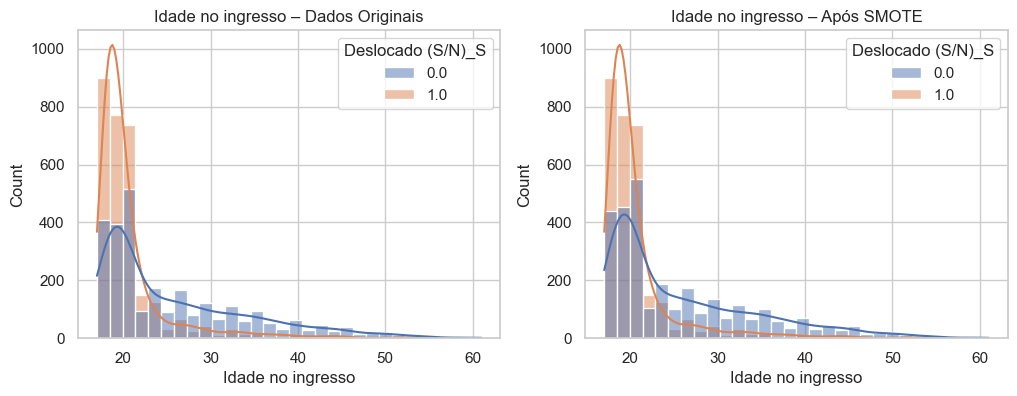

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=dt_processed, x="Idade no ingresso", hue="Deslocado (S/N)_S", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Idade no ingresso – Dados Originais")

temp_df_smote = pd.DataFrame({'Idade no ingresso': X_res["Idade no ingresso"], 'Deslocado (S/N)_S': y_res})
sns.histplot(data=temp_df_smote, x="Idade no ingresso", hue="Deslocado (S/N)_S", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Idade no ingresso – Após SMOTE")

plt.show()

A alteração é muito subtil, mas ligeiramente notavel entre os 19 anos, representando assim o cenário de se tivessemos o mesmo número de deslocados e nativos.
Podemos também verificar que as distribuição estatistica mantém-se. No exemplo seguinte verificamos as alteração são insignificantes no valores médios das variáveis numéricas.

In [197]:
stats_original = X.assign(Deslocado=y).groupby("Deslocado").mean()
stats_smote = X_res.assign(Deslocado=y_res).groupby("Deslocado").mean()
df_diff = (stats_smote - stats_original).round(2)

df_diff

,Ordem de ingresso,Nota ingresso,Bolseiro,Idade no ingresso,Habilitação literária mãe (classe),Escola (classe),Curso (classe),Estado civil (classe),Situação profissional mãe (classe),Situação profissional pai (classe),...,Nr. anos de curso,Família de risco,Origem de país de acordo ortográfico,Origem de país da UE,Origem de país do continente americano,Origem de país estrangeiro,Origem de país do continente euroásiatico,Origem de país do continente africano,Nota ingresso (Norm),Idade no ingresso (Norm)
Deslocado,,,,,,,,,,,,,,,,,,,,,
0.0,0.0,0.04,0.0,-0.04,-0.01,-0.01,-0.01,0.0,-0.01,-0.0,...,-0.0,-0.01,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0
1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Parte 5 — Visualização e storytelling
Nesta parte do trabalho pretende-se sintetizar os principais resultados da análise através de visualizações interativas adequadas e construir uma narrativa clara que permita compreender o perfil dos estudantes e os fatores potencialmente associados ao sucesso académico.

Para o efeito, deverá utilizar o Looker Studio, com o objetivo de:
- Comunicar de forma clara e intuitiva os padrões identificados nos dados;
- Apoiar a interpretação dos resultados obtidos nas fases de análise exploratória e preparação dos dados;
- Criar uma base visual interativa que suporte decisões;
- Estabelecer uma narrativa coerente que apoie a tomada de decisão informada.

Deve organizar os dashboards nas áreas que entender mais relevantes (caracterização global dos estudantes, comparação entre diplomados e não diplomados, análise de fatores potencialmente
associados ao sucesso académico, etc).

Sempre que possível, deverão ser utilizados filtros globais adequados (por exemplo, Curso ou Categoria) para permitir uma análise interativa e direcionada.

[Link de acesso ao recurso de Looker Studio](https://lookerstudio.google.com/s/sFjedzK3Vp4)